# 🚗 Vehicle Sales — Data Cleaning & EDA
**Dataset:** ~558k used vehicle auction records | Jan 2014 – Jul 2015  
**Goal:** Clean the data, then extract and visualize key insights inline.

## 1. Imports & Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
PALETTE = ['#1E3A5F','#2D6A9F','#4CA3DD','#7EC8E3','#FFB347','#FF6B35','#A3C4BC']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': '#F7F9FC',
                     'axes.facecolor': '#F7F9FC', 'axes.titlesize': 13,
                     'axes.titleweight': 'bold'})

RAW_PATH     = '/home/mennatullah/Documents/repos/li/AI/instant/hackathon/VehicleSales.parquet'
CLEANED_PATH = '/home/mennatullah/Documents/repos/li/AI/instant/hackathon/VehicleSales_cleaned.parquet'


## 2. Load Raw Data & Initial Audit

In [30]:
raw = pd.read_parquet(RAW_PATH)
print(f'Shape: {raw.shape}')
raw.head(5)

Shape: (558837, 17)


,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [31]:
# Data types & memory
raw.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Id              558837 non-null  int64         
 1   Year            558837 non-null  int64         
 2   Make            548536 non-null  str           
 3   Model           548438 non-null  str           
 4   Trim            548186 non-null  str           
 5   Body            545642 non-null  str           
 6   Transmission    493485 non-null  str           
 7   VIN             558833 non-null  str           
 8   State           558837 non-null  str           
 9   ConditionValue  547017 non-null  float64       
 10  Odometer        558743 non-null  float64       
 11  Color           558088 non-null  str           
 12  Interior        558088 non-null  str           
 13  Seller          558837 non-null  str           
 14  MMR             558799 non-null  float64       

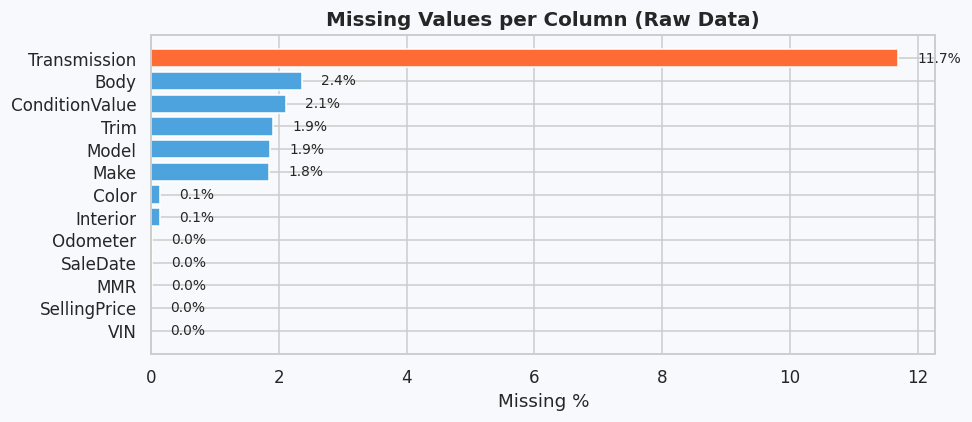

In [32]:
# Null audit — visualised
null_pct = (raw.isnull().sum() / len(raw) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(null_pct.index[::-1], null_pct.values[::-1],
               color=['#FF6B35' if v > 10 else '#4CA3DD' for v in null_pct.values[::-1]])
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column (Raw Data)')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
# Descriptive stats for numeric columns
raw.describe().round(2)

,Id,Year,ConditionValue,Odometer,MMR,SellingPrice,SaleDate
count,558837.00,558837.00,547017.00,558743.00,558799.00,558825.00,558799
mean,279420.00,2010.04,30.67,68320.02,13769.38,13611.36,2015-03-06 00:09:10.521386
min,2.00,1982.00,1.00,1.00,25.00,1.00,2014-01-01 01:15:00
25%,139711.00,2007.00,23.00,28371.00,7100.00,6900.00,2015-01-20 18:00:00
50%,279420.00,2012.00,35.00,52254.00,12250.00,12100.00,2015-02-12 19:20:00
75%,419129.00,2013.00,42.00,99109.00,18300.00,18200.00,2015-05-21 19:00:00
max,558838.00,2015.00,49.00,999999.00,182000.00,230000.00,2015-07-20 19:30:00
std,161322.49,3.97,13.40,53398.54,9679.97,9749.50,NaN


## 3. Data Cleaning

In [34]:
# Start from the pre-cleaned parquet (already has basic fixes applied)
# We load it and apply further cleaning on top
df = pd.read_parquet(CLEANED_PATH)
print(f'Starting shape: {df.shape}')

Starting shape: (557966, 17)


In [35]:
# ── 3.1  Fix Transmission mislabels ────────────────────────────────────────
print('Before fix:', df['Transmission'].value_counts().to_dict())
df['Transmission'] = df['Transmission'].replace({'sedan': 'automatic', 'Sedan': 'automatic'})
print('After fix: ', df['Transmission'].value_counts().to_dict())

Before fix: {'automatic': 475236, 'manual': 17506, 'sedan': 15, 'Sedan': 11}
After fix:  {'automatic': 475262, 'manual': 17506}


In [36]:
# ── 3.2  Parse dates ───────────────────────────────────────────────────────
df['SaleDate'] = pd.to_datetime(df['SaleDate'], errors='coerce')
# Drop rows where we can't place the sale in time
before = len(df)
df.dropna(subset=['SaleDate', 'SellingPrice', 'MMR'], inplace=True)
print(f'Dropped {before - len(df)} rows with null SaleDate / SellingPrice / MMR')

Dropped 26 rows with null SaleDate / SellingPrice / MMR


In [37]:
# ── 3.3  Remove price outliers (IQR method) ────────────────────────────────
Q1, Q3 = df['SellingPrice'].quantile([0.01, 0.99])
before = len(df)
df = df[(df['SellingPrice'] >= Q1) & (df['SellingPrice'] <= Q3)]
print(f'Outlier removal kept {len(df):,} rows  (dropped {before-len(df):,})')

Outlier removal kept 547,166 rows  (dropped 10,774)


In [38]:
# ── 3.4  Standardise categorical case ──────────────────────────────────────
for col in ['Make', 'Model', 'Body', 'Color', 'Interior', 'State']:
    df[col] = df[col].str.strip().str.title()
df['Transmission'] = df['Transmission'].str.strip().str.lower()
print('Standardised: Make, Model, Body, Color, Interior, State, Transmission')

Standardised: Make, Model, Body, Color, Interior, State, Transmission


In [39]:
# ── 3.5  Feature engineering ───────────────────────────────────────────────
df['SaleYear']      = df['SaleDate'].dt.year
df['SaleMonth']     = df['SaleDate'].dt.to_period('M').astype(str)
df['SaleQuarter']   = df['SaleDate'].dt.to_period('Q').astype(str)
df['VehicleAge']    = df['SaleYear'] - df['Year']           # age at time of sale
df['PriceDiff']     = df['SellingPrice'] - df['MMR']        # above/below market
df['PriceDiffPct']  = (df['PriceDiff'] / df['MMR']) * 100

bins   = [0, 5000, 10000, 15000, 20000, 30000, 50000, 999999]
labels = ['<$5k','$5-10k','$10-15k','$15-20k','$20-30k','$30-50k','>$50k']
df['PriceBand'] = pd.cut(df['SellingPrice'], bins=bins, labels=labels)

print(f'Final clean shape: {df.shape}')
df.head(3)

Final clean shape: (547166, 24)


,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,...,MMR,SellingPrice,SaleDate,SaleYear,SaleMonth,SaleQuarter,VehicleAge,PriceDiff,PriceDiffPct,PriceBand
0,2,2015,Kia,Sorento,Lx,Suv,automatic,5xyktca69fg566472,Ca,5.0,...,20500.0,21500.0,2014-12-16 04:30:00,2014,2014-12,2014Q4,-1,1000.0,4.878049,$20-30k
1,3,2015,Kia,Sorento,Lx,Suv,automatic,5xyktca69fg561319,Ca,5.0,...,20800.0,21500.0,2014-12-16 04:30:00,2014,2014-12,2014Q4,-1,700.0,3.365385,$20-30k
2,4,2014,Bmw,3 Series,328I Sulev,Sedan,automatic,wba3c1c51ek116351,Ca,45.0,...,31900.0,30000.0,2015-01-14 20:30:00,2015,2015-01,2015Q1,1,-1900.0,-5.956113,$20-30k


In [40]:
# ── 3.6  Post-cleaning null summary ────────────────────────────────────────
null_post = df.isnull().sum()
null_post[null_post > 0]

Make               9697
Model              9709
Transmission      63706
ConditionValue    11366
dtype: int64

## 4. EDA — Market Overview

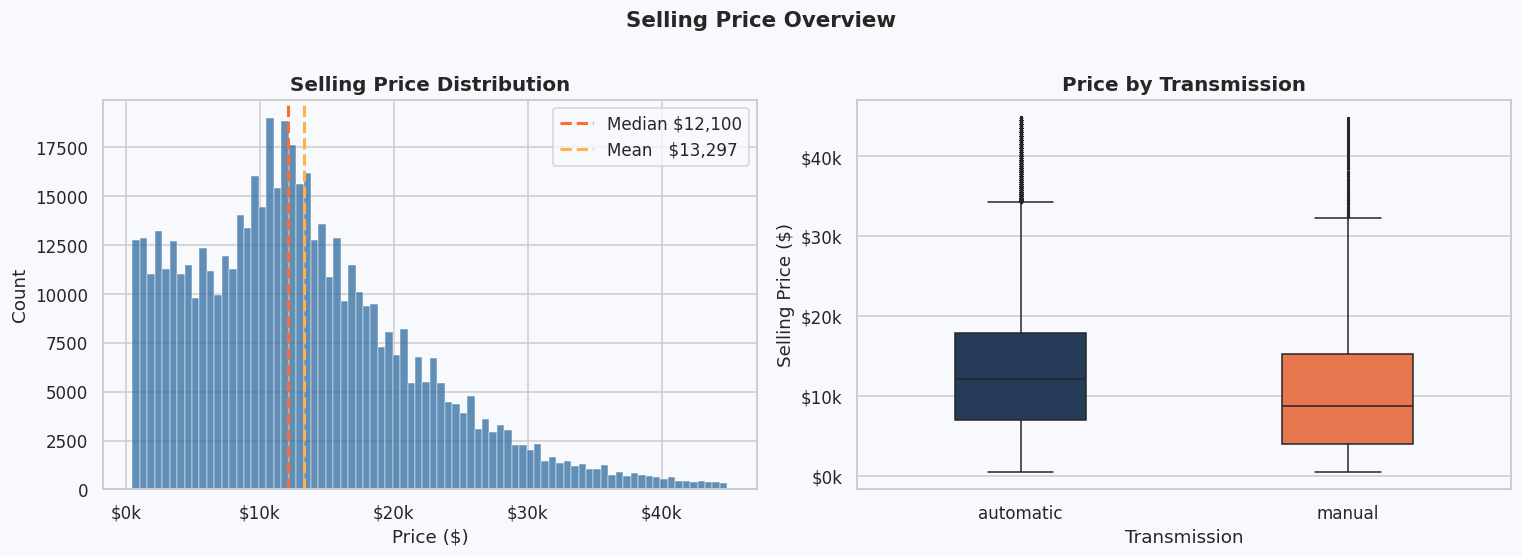

In [41]:
# ── 4.1  Selling price distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['SellingPrice'], bins=80, ax=axes[0], color=PALETTE[1],
             edgecolor='white', linewidth=0.3)
axes[0].axvline(df['SellingPrice'].median(), color='#FF6B35', lw=2, ls='--', label=f'Median ${df["SellingPrice"].median():,.0f}')
axes[0].axvline(df['SellingPrice'].mean(),   color='#FFB347', lw=2, ls='--', label=f'Mean   ${df["SellingPrice"].mean():,.0f}')
axes[0].set_title('Selling Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

# Box by transmission
trans_df = df[df['Transmission'].isin(['automatic','manual'])]
sns.boxplot(data=trans_df, x='Transmission', y='SellingPrice', ax=axes[1],
            palette=[PALETTE[0], PALETTE[5]], width=0.4, fliersize=1)
axes[1].set_title('Price by Transmission')
axes[1].set_ylabel('Selling Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

plt.suptitle('Selling Price Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

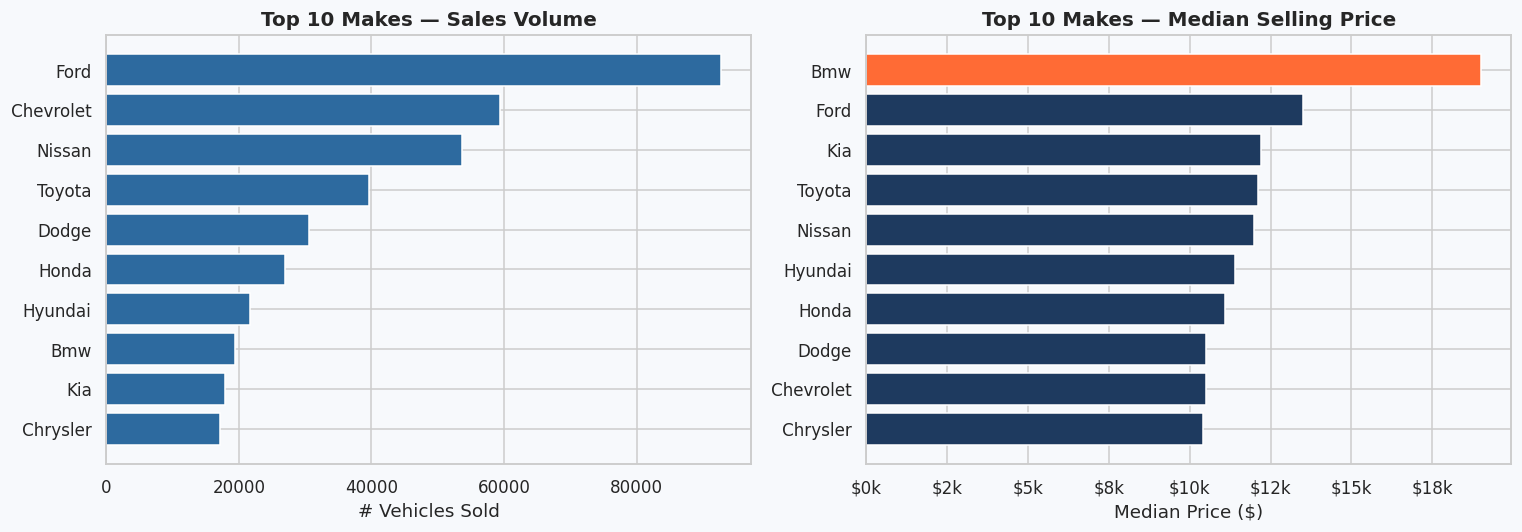

In [42]:
# ── 4.2  Volume & price by Make ───────────────────────────────────────────
top10 = df['Make'].value_counts().head(10)
med_price = df[df['Make'].isin(top10.index)].groupby('Make')['SellingPrice'].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10.index[::-1], top10.values[::-1], color=PALETTE[1])
axes[0].set_title('Top 10 Makes — Sales Volume')
axes[0].set_xlabel('# Vehicles Sold')

colors = ['#FF6B35' if v == med_price.max() else PALETTE[0] for v in med_price.values]
axes[1].barh(med_price.index, med_price.values, color=colors)
axes[1].set_title('Top 10 Makes — Median Selling Price')
axes[1].set_xlabel('Median Price ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

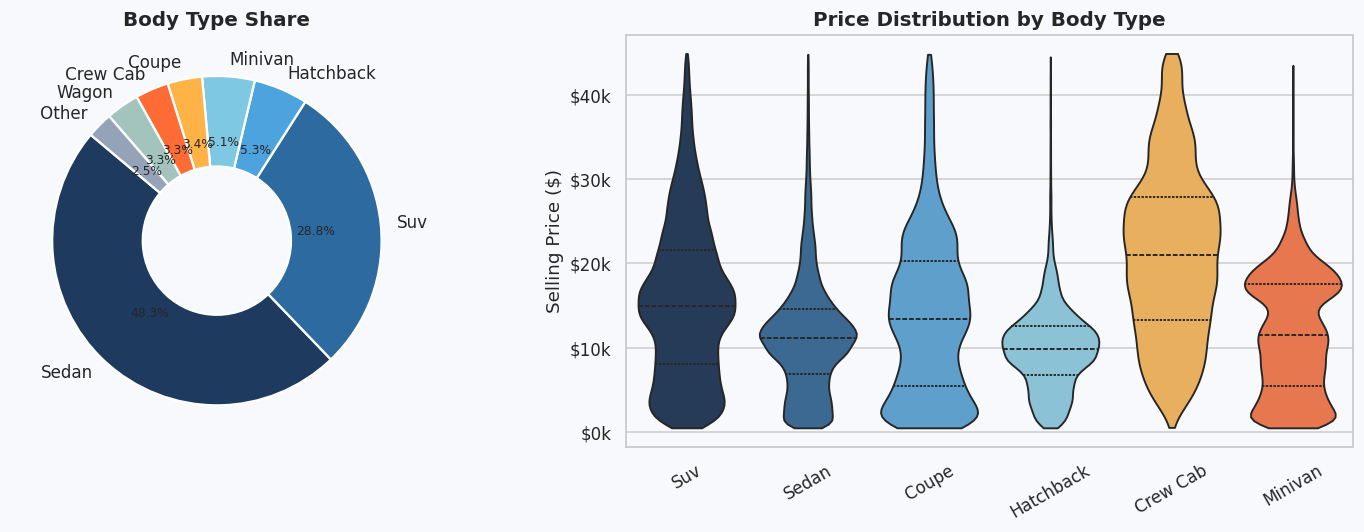

In [43]:
# ── 4.3  Body type breakdown ──────────────────────────────────────────────
top_bodies = df['Body'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wedges, texts, autotexts = axes[0].pie(
    top_bodies.values, labels=top_bodies.index, autopct='%1.1f%%',
    colors=PALETTE + ['#94A3B8'], startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5))
for t in autotexts: t.set_fontsize(8)
axes[0].set_title('Body Type Share')

top6b = df['Body'].value_counts().head(6).index
sns.violinplot(data=df[df['Body'].isin(top6b)], x='Body', y='SellingPrice',
               ax=axes[1], palette=PALETTE[:6], inner='quartile', cut=0)
axes[1].set_title('Price Distribution by Body Type')
axes[1].set_ylabel('Selling Price ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

## 5. EDA — Pricing Intelligence

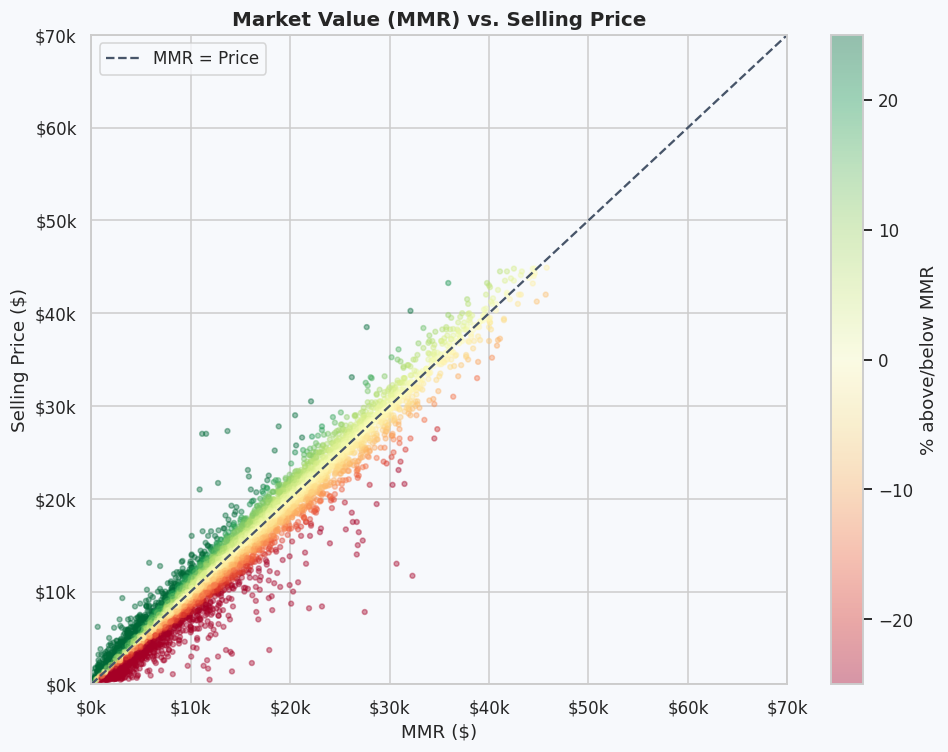

Pearson r = 0.9801  (p = 0.00e+00)  — strong positive correlation as expected


In [44]:
# ── 5.1  MMR vs Selling Price (market alignment) ──────────────────────────
sample = df.dropna(subset=['MMR']).sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(sample['MMR'], sample['SellingPrice'],
                c=sample['PriceDiffPct'], cmap='RdYlGn',
                alpha=0.4, s=10, vmin=-25, vmax=25)
ax.plot([0, 80000], [0, 80000], color='#475569', lw=1.5, ls='--', label='MMR = Price')
plt.colorbar(sc, ax=ax, label='% above/below MMR')
ax.set_xlim(0, 70000); ax.set_ylim(0, 70000)
ax.set_title('Market Value (MMR) vs. Selling Price')
ax.set_xlabel('MMR ($)'); ax.set_ylabel('Selling Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df.dropna(subset=['MMR'])['MMR'], df.dropna(subset=['MMR'])['SellingPrice'])
print(f'Pearson r = {r:.4f}  (p = {p:.2e})  — strong positive correlation as expected')

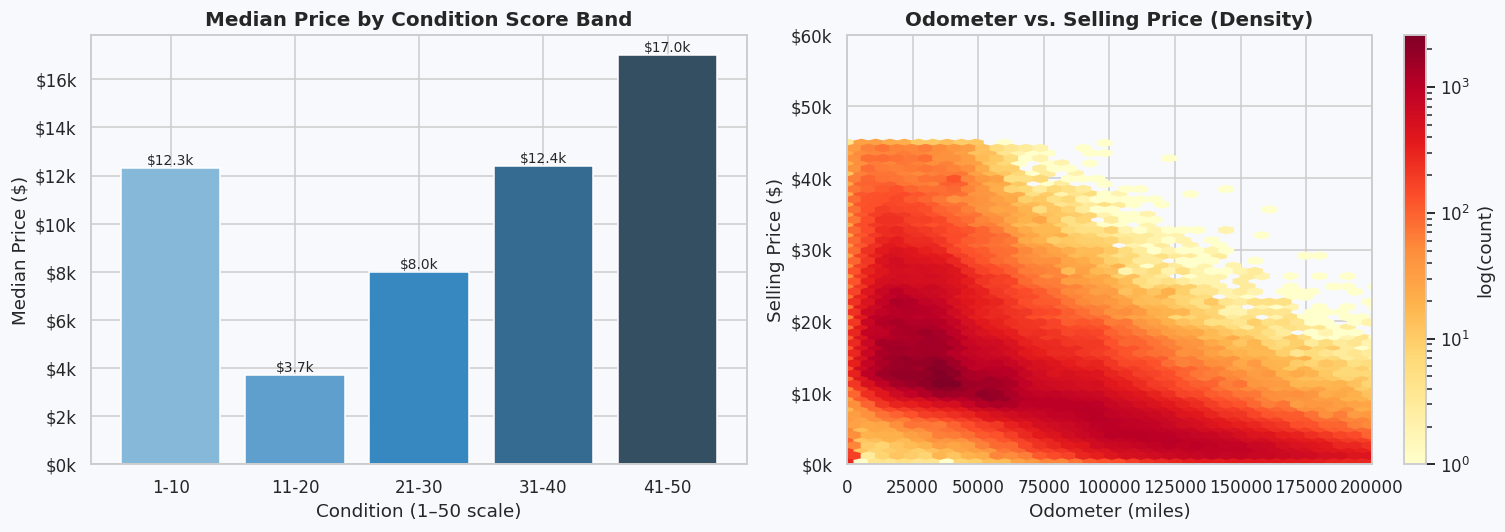

In [45]:
# ── 5.2  Condition score vs price ─────────────────────────────────────────
cond_df = df.dropna(subset=['ConditionValue']).copy()
cond_df['CondBin'] = pd.cut(cond_df['ConditionValue'],
                              bins=[0,10,20,30,40,50],
                              labels=['1-10','11-20','21-30','31-40','41-50'])
cond_price = cond_df.groupby('CondBin', observed=True)['SellingPrice'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cond_price.index.astype(str), cond_price.values,
            color=sns.color_palette('Blues_d', len(cond_price)))
axes[0].set_title('Median Price by Condition Score Band')
axes[0].set_xlabel('Condition (1–50 scale)'); axes[0].set_ylabel('Median Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
for i, v in enumerate(cond_price.values):
    axes[0].text(i, v+150, f'${v/1e3:.1f}k', ha='center', fontsize=9)

# Odometer vs price (hexbin)
hb = axes[1].hexbin(df['Odometer'], df['SellingPrice'],
                     gridsize=55, cmap='YlOrRd', mincnt=1, bins='log')
plt.colorbar(hb, ax=axes[1], label='log(count)')
axes[1].set_xlim(0, 200000); axes[1].set_ylim(0, 60000)
axes[1].set_title('Odometer vs. Selling Price (Density)')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Selling Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

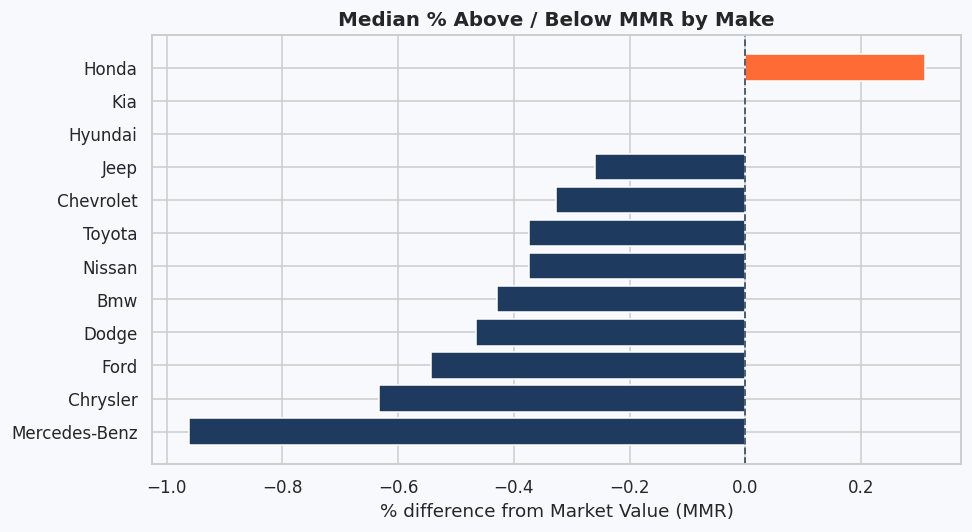

In [46]:
# ── 5.3  Who sells above/below MMR? ──────────────────────────────────────
makes_diff = (df[df['Make'].isin(df['Make'].value_counts().head(12).index)]
              .groupby('Make')['PriceDiffPct'].median().sort_values())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#FF6B35' if v > 0 else '#1E3A5F' for v in makes_diff.values]
ax.barh(makes_diff.index, makes_diff.values, color=colors)
ax.axvline(0, color='#475569', lw=1.2, ls='--')
ax.set_title('Median % Above / Below MMR by Make')
ax.set_xlabel('% difference from Market Value (MMR)')
plt.tight_layout()
plt.show()

## 6. EDA — Time Trends

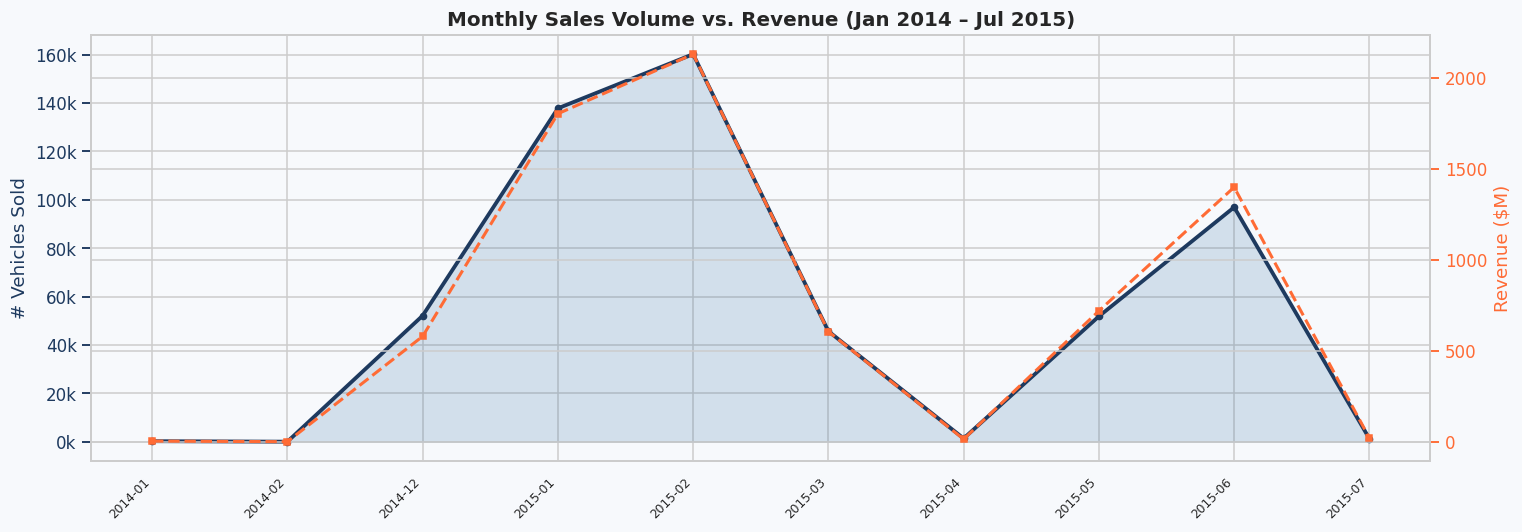

In [47]:
# ── 6.1  Monthly sales volume + revenue ──────────────────────────────────
monthly_vol = df.groupby('SaleMonth').size().sort_index()
monthly_rev = df.groupby('SaleMonth')['SellingPrice'].sum().sort_index() / 1e6

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
x = range(len(monthly_vol))
ax1.fill_between(x, monthly_vol.values, alpha=0.18, color=PALETTE[1])
ax1.plot(x, monthly_vol.values, color=PALETTE[0], lw=2.5, marker='o', ms=4, label='Volume')
ax2.plot(x, monthly_rev.values, color='#FF6B35', lw=2, ls='--', marker='s', ms=4, label='Revenue')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_vol.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('# Vehicles Sold', color=PALETTE[0])
ax2.set_ylabel('Revenue ($M)',     color='#FF6B35')
ax1.set_title('Monthly Sales Volume vs. Revenue (Jan 2014 – Jul 2015)')
ax1.tick_params(axis='y', colors=PALETTE[0])
ax2.tick_params(axis='y', colors='#FF6B35')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

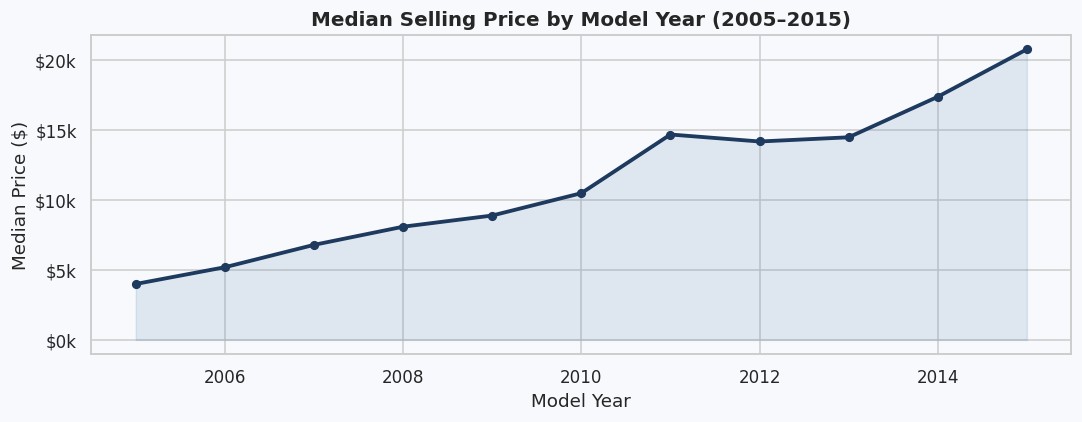

In [48]:
# ── 6.2  Median price by model year ──────────────────────────────────────
yr_price = df[df['Year'] >= 2005].groupby('Year')['SellingPrice'].median()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yr_price.index, yr_price.values, color=PALETTE[0], lw=2.5, marker='o', ms=5)
ax.fill_between(yr_price.index, yr_price.values, alpha=0.12, color=PALETTE[1])
ax.set_title('Median Selling Price by Model Year (2005–2015)')
ax.set_xlabel('Model Year'); ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

## 7. EDA — Correlation & Heatmaps

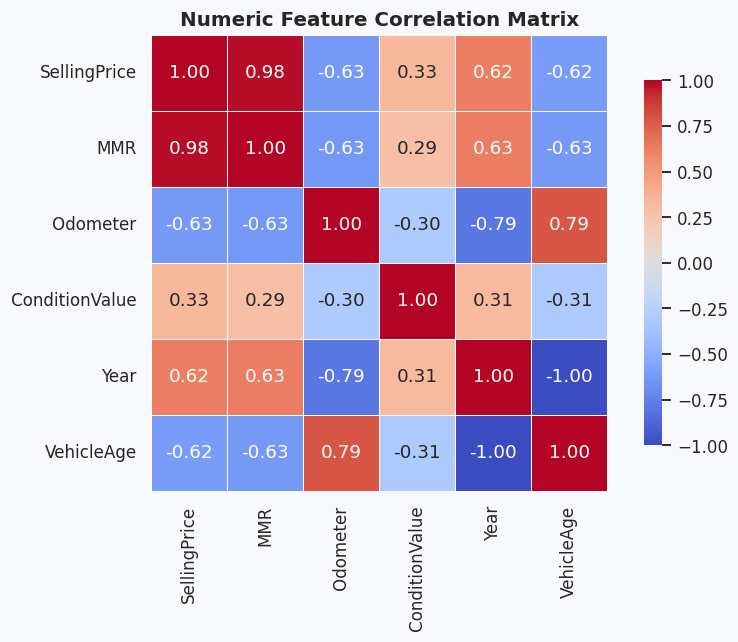

In [49]:
# ── 7.1  Numeric correlation matrix ──────────────────────────────────────
num_cols = ['SellingPrice', 'MMR', 'Odometer', 'ConditionValue', 'Year', 'VehicleAge']
corr = df[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

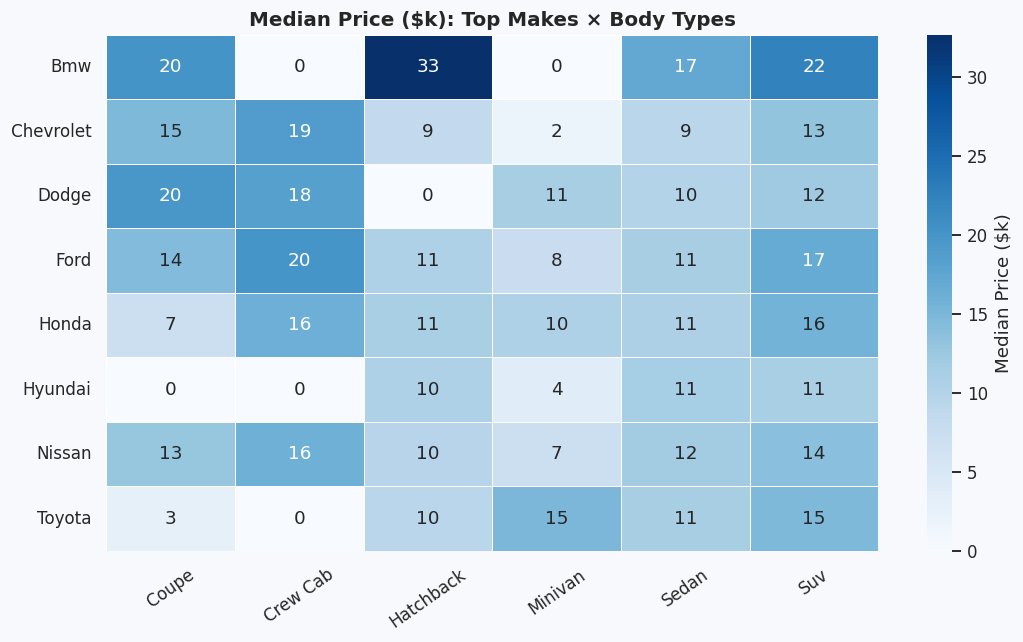

In [50]:
# ── 7.2  Make × Body type price heatmap ──────────────────────────────────
top8m  = df['Make'].value_counts().head(8).index
top6b2 = df['Body'].value_counts().head(6).index
heat   = (df[df['Make'].isin(top8m) & df['Body'].isin(top6b2)]
          .groupby(['Make','Body'])['SellingPrice'].median()
          .unstack().fillna(0) / 1000)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Median Price ($k)'})
ax.set_title('Median Price ($k): Top Makes × Body Types')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 8. Key Findings Summary

In [51]:
print('='*60)
print('KEY FINDINGS')
print('='*60)
print(f'Total clean records  : {len(df):,}')
print(f'Sale period          : {df["SaleDate"].min().date()} → {df["SaleDate"].max().date()}')
print(f'Median selling price : ${df["SellingPrice"].median():,.0f}')
print(f'Avg vehicle age      : {df["VehicleAge"].mean():.1f} years at sale')
print(f'Top Make by volume   : {df["Make"].value_counts().idxmax()} ({df["Make"].value_counts().max():,} units)')
print(f'Top Make by price    : {df.groupby("Make")["SellingPrice"].median().idxmax()}')
print(f'Automatic share      : {(df["Transmission"]=="automatic").mean()*100:.1f}%')
r2, _ = stats.pearsonr(df.dropna(subset=["MMR"])["MMR"], df.dropna(subset=["MMR"])["SellingPrice"])
print(f'MMR-Price correlation: r = {r2:.4f}')
print(f'% sold above MMR     : {(df["PriceDiff"] > 0).mean()*100:.1f}%')

KEY FINDINGS
Total clean records  : 547,166
Sale period          : 2014-01-01 → 2015-07-20
Median selling price : $12,100
Avg vehicle age      : 4.8 years at sale
Top Make by volume   : Ford (92,681 units)
Top Make by price    : Bentley
Automatic share      : 85.3%
MMR-Price correlation: r = 0.9801
% sold above MMR     : 47.1%


In [53]:
# Save the clean dataframe for the Dash app
df.to_parquet('/home/mennatullah/Documents/repos/li/AI/instant/hackathon/vehicle_sales_final.parquet', index=False)
print('Saved cleaned data → vehicle_sales_final.parquet')

Saved cleaned data → vehicle_sales_final.parquet
